<a href="https://colab.research.google.com/github/Hassan-Amir-debug/UCI---Autism-Spectrum-Disorder-data-of-Children/blob/main/ASD_data_of_children_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

df = pd.read_csv("/content/Autism-Child-Data.csv")
df.head()


,id,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,0,0,1,1,0,1,0,...,m,Others,no,no,Jordan,no,5,4-11 years,Parent,NO
1,2,1,1,0,0,1,1,0,1,0,...,m,Middle Eastern,no,no,Jordan,no,5,4-11 years,Parent,NO
2,3,1,1,0,0,0,1,1,1,0,...,m,?,no,no,Jordan,yes,5,4-11 years,?,NO
3,4,0,1,0,0,1,1,0,0,0,...,f,?,yes,no,Jordan,no,4,4-11 years,?,NO
4,5,1,1,1,1,1,1,1,1,1,...,m,Others,yes,no,United States,no,10,4-11 years,Parent,YES


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
print(df.columns)


Index(['id', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'jundice', 'austim', 'used_app_before', 'result', 'Class/ASD',
       'ethnicity_Asian', 'ethnicity_Black', 'ethnicity_Hispanic',
       'ethnicity_Latino', 'ethnicity_Middle Eastern ', 'ethnicity_Others',
       'ethnicity_Pasifika', 'ethnicity_South Asian', 'ethnicity_Turkish',
       'ethnicity_White-European', 'contry_of_res_Argentina',
       'contry_of_res_Armenia', 'contry_of_res_Australia',
       'contry_of_res_Austria', 'contry_of_res_Bahrain',
       'contry_of_res_Bangladesh', 'contry_of_res_Bhutan',
       'contry_of_res_Brazil', 'contry_of_res_Bulgaria',
       'contry_of_res_Canada', 'contry_of_res_China',
       'contry_of_res_Costa Rica', 'contry_of_res_Egypt',
       'contry_of_res_Europe', 'contry_of_res_Georgia',
       'contry_of_res_Germany', 'contry_of_res_Ghana', 'contry_of_res_India',
       'contry

In [ ]:
# Fill numerical columns with median
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill binary categorical columns with mode
binary_cols = ['gender','jundice','austim','used_app_before','Class/ASD']
for col in binary_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify missing values
print(df.isnull().sum())


id                  0
A1_Score            0
A2_Score            0
A3_Score            0
A4_Score            0
A5_Score            0
A6_Score            0
A7_Score            0
A8_Score            0
A9_Score            0
A10_Score           0
age                 0
gender              0
ethnicity          43
jundice             0
austim              0
contry_of_res       0
used_app_before     0
result              0
age_desc            0
relation           43
Class/ASD           0
dtype: int64


In [ ]:
binary_cols = ['gender','jundice','austim','used_app_before','Class/ASD']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df[binary_cols].head()


,gender,jundice,austim,used_app_before,Class/ASD
0,1,0,0,0,0
1,1,0,0,0,0
2,1,0,0,1,0
3,0,1,0,0,0
4,1,1,0,0,1


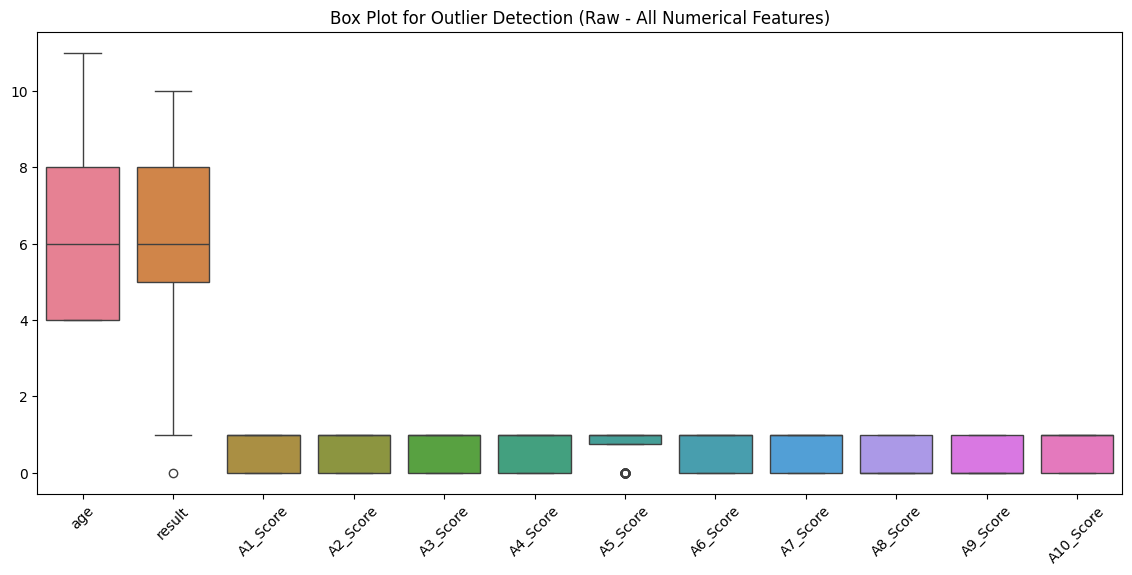

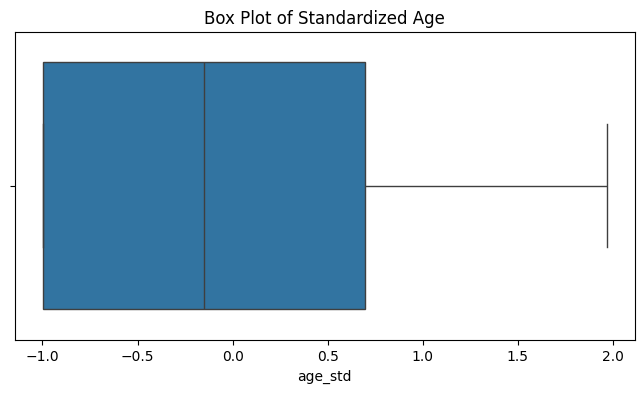

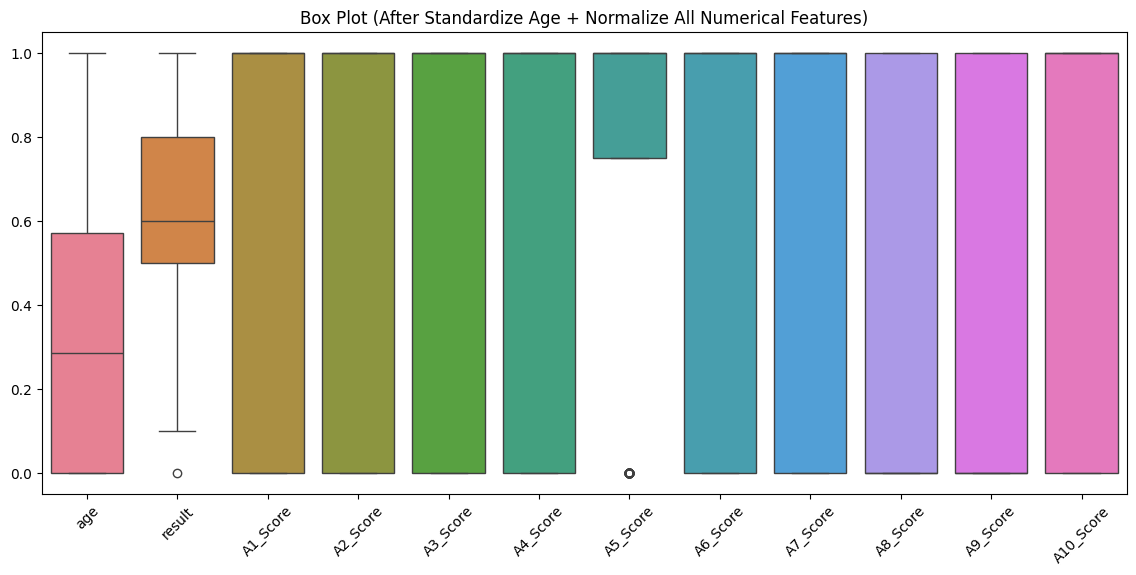

Standardized Table:
     Age  result  A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  \
0 -0.150     5.0         1         1         0         0         1         1   
1 -0.150     5.0         1         1         0         0         1         1   
2 -0.150     5.0         1         1         0         0         0         1   
3 -0.573     4.0         0         1         0         0         1         1   
4 -0.573    10.0         1         1         1         1         1         1   

   A7_Score  A8_Score  A9_Score  A10_Score  
0         0         1         0          0  
1         0         1         0          0  
2         1         1         0          0  
3         0         0         0          1  
4         1         1         1          1  
Final Normalized Dataset Shape: (288, 22)
        age  result  A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  \
0  0.285714     0.5       1.0       1.0       0.0       0.0       1.0   
1  0.285714     0.5       1.0       1.0  

In [ ]:
from scipy.io import arff
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1 Load Dataset (.arff)
file_path = "/content/Autism-Child-Data.arff"
data, meta = arff.loadarff(file_path)
df = pd.DataFrame(data)

# Decode byte strings -> normal strings
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.decode('utf-8')

# 2 Ensure numeric types for required columns
score_cols = [
    'A1_Score','A2_Score','A3_Score','A4_Score','A5_Score','A6_Score','A7_Score','A8_Score','A9_Score','A10_Score']
df[score_cols] = df[score_cols].astype(int)
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['result'] = pd.to_numeric(df['result'], errors='coerce')

# Drop rows with NaN in numeric columns
df = df.dropna(subset=['age', 'result'] + score_cols).reset_index(drop=True)
all_num_features = ['age', 'result'] + score_cols

# 3 BOX PLOT (RAW)
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[all_num_features], showfliers=True)
plt.title("Box Plot for Outlier Detection (Raw - All Numerical Features)")
plt.xticks(rotation=45)
plt.show()

# 4 STANDARDIZE AGE ONLY
age_std_scaler = StandardScaler()
df['age_std'] = age_std_scaler.fit_transform(df[['age']])

# 5) BOX PLOT - Standardized Age
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['age_std'])
plt.title("Box Plot of Standardized Age")
plt.xlabel("age_std")
plt.show()

# 6 NORMALIZE ALL NUMERICAL FEATURES (0-1)
df_norm_input = df[['age_std', 'result'] + score_cols].copy()
minmax = MinMaxScaler()
df_norm = df.copy()
df_norm[['age', 'result'] + score_cols] = minmax.fit_transform(df_norm_input)

# 7 BOX PLOT (AFTER NORMALIZATION)
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_norm[['age', 'result'] + score_cols], showfliers=True)
plt.title("Box Plot (After Standardize Age + Normalize All Numerical Features)")
plt.xticks(rotation=45)
plt.show()

# 8 CREATE STANDARDIZED TABLE FOR REPORT

# Include standardized age, original scores, and result
standardized_table = df[['age_std', 'result'] + score_cols].copy()
standardized_table = standardized_table.rename(columns={'age_std': 'Age'})

# 9 Round values for better report readability
standardized_table = standardized_table.round(3)

print("Standardized Table:")
print(standardized_table.head(5))

# 10 Final Output
print("Final Normalized Dataset Shape:", df_norm.shape)
print(df_norm[['age', 'result'] + score_cols].head())


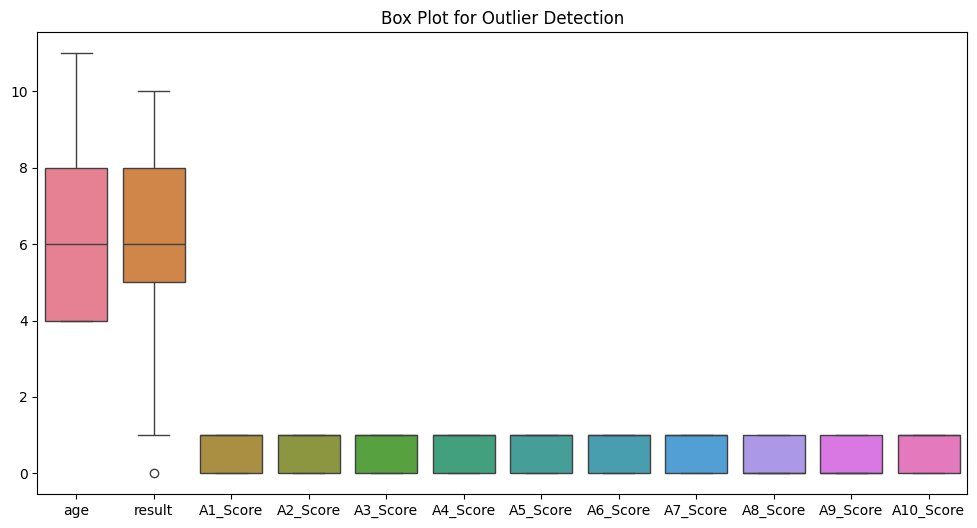

In [ ]:
numerical_cols = ['age','result','A1_Score','A2_Score','A3_Score','A4_Score',
                  'A5_Score','A6_Score','A7_Score','A8_Score','A9_Score','A10_Score']

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numerical_cols])
plt.title("Box Plot for Outlier Detection")
plt.show()


In [ ]:
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

df[numerical_cols].head()


,age,result,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score
0,-0.148931,-0.543509,0.760512,0.9337,-1.700980,-1.108606,0.587896,0.635489,-1.240617,1.006873,-0.986394,-1.627882
1,-0.148931,-0.543509,0.760512,0.9337,-1.700980,-1.108606,0.587896,0.635489,-1.240617,1.006873,-0.986394,-1.627882
2,-0.148931,-0.543509,0.760512,0.9337,-1.700980,-1.108606,-1.700980,0.635489,0.806051,1.006873,-0.986394,-1.627882
3,-0.575284,-0.981920,-1.314904,0.9337,-1.700980,-1.108606,0.587896,0.635489,-1.240617,-0.993174,-0.986394,0.614295
4,-0.575284,1.648545,0.760512,0.9337,0.587896,0.902034,0.587896,0.635489,0.806051,1.006873,1.013794,0.614295


In [ ]:
minmax = MinMaxScaler()
df[numerical_cols] = minmax.fit_transform(df[numerical_cols])

df[numerical_cols].head()


,age,result,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score
0,0.285714,0.5,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
1,0.285714,0.5,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,0.285714,0.5,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
3,0.142857,0.4,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,0.142857,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [ ]:
from scipy.io import arff

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1 LOAD ARFF
arff_path = "Autism-Child-Data.arff"   # <-- your uploaded file
data, meta = arff.loadarff(arff_path)
df = pd.DataFrame(data)

# decode bytes -> string
df = df.map(lambda x: x.decode("utf-8") if isinstance(x, (bytes, bytearray)) else x)

# missing values handling: '?' -> NaN
df = df.replace("?", np.nan)

# target column
target_col = "Class/ASD"

# map target to 0/1
df[target_col] = df[target_col].map({"YES": 1, "NO": 0, "yes": 1, "no": 0}).astype("Int64")

X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# 2 SPLIT: Train / Test1 / Test2 (60/20/20)
X_tmp, X_test2, y_tmp, y_test2 = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_test1, y_train, y_test1 = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)

# 3 PREPROCESS
# numeric -> median impute + standardize
# categorical -> mode impute + one-hot
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

def metrics_row(model_name, dataset_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4 LOGISTIC REGRESSION + L1/L2 REGULARIZATION
# (select best via 5-fold CV using F1)
lr_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=5000, solver="liblinear"))
])

param_grid_lr = [
    {"clf__penalty": ["l2"], "clf__C": [0.01, 0.1, 1, 10, 100]},
    {"clf__penalty": ["l1"], "clf__C": [0.01, 0.1, 1, 10, 100]},
]

grid_lr = GridSearchCV(lr_pipe, param_grid=param_grid_lr, scoring="f1", cv=skf, n_jobs=1)
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
print("Best Logistic Regression params:", grid_lr.best_params_)
print("Best LR CV F1:", grid_lr.best_score_)
print("Final LogReg coef_ shape:", best_lr.named_steps["clf"].coef_.shape)

# Evaluate LR on Train/Test1/Test2
results = []
for name, Xd, yd in [("Train", X_train, y_train), ("Test1", X_test1, y_test1), ("Test2", X_test2, y_test2)]:
    pred = best_lr.predict(Xd)
    results.append(metrics_row("LogReg(best L1/L2)", name, yd, pred))

# 5 KNN + K-FOLD CV TO SELECT k
knn_pipe = Pipeline([
    ("prep", preprocess),
    ("knn", KNeighborsClassifier())
])

param_grid_knn = {"knn__n_neighbors": list(range(1, 32, 2))}  # odd k 1..31
grid_knn = GridSearchCV(knn_pipe, param_grid=param_grid_knn, scoring="f1", cv=skf, n_jobs=1)
grid_knn.fit(X_train, y_train)

best_k = grid_knn.best_params_["knn__n_neighbors"]
best_knn = grid_knn.best_estimator_

print("Best KNN k:", best_k)
print("Best KNN CV F1:", grid_knn.best_score_)

# Evaluate KNN on Train/Test1/Test2
for name, Xd, yd in [("Train", X_train, y_train), ("Test1", X_test1, y_test1), ("Test2", X_test2, y_test2)]:
    pred = best_knn.predict(Xd)
    results.append(metrics_row(f"KNN(k={best_k})", name, yd, pred))

# 6 PRINT + SAVE RESULTS
results_df = pd.DataFrame(results)
print("\n=== Results (Accuracy/Precision/Recall/F1) ===")
print(results_df.to_string(index=False))

results_df.to_csv("model_results_autism_child_from_uploaded_arff.csv", index=False)
print("\nSaved: model_results_autism_child_from_uploaded_arff.csv")

Best Logistic Regression params: {'clf__C': 0.1, 'clf__penalty': 'l1'}
Best LR CV F1: 1.0
Final LogReg coef_ shape: (1, 84)
Best KNN k: 9
Best KNN CV F1: 0.9066666666666666

=== Results (Accuracy/Precision/Recall/F1) ===
             Model Dataset  Accuracy  Precision   Recall       F1
LogReg(best L1/L2)   Train  1.000000   1.000000 1.000000 1.000000
LogReg(best L1/L2)   Test1  1.000000   1.000000 1.000000 1.000000
LogReg(best L1/L2)   Test2  1.000000   1.000000 1.000000 1.000000
          KNN(k=9)   Train  0.954023   0.913043 1.000000 0.954545
          KNN(k=9)   Test1  0.898305   0.848485 0.965517 0.903226
          KNN(k=9)   Test2  0.898305   0.823529 1.000000 0.903226

Saved: model_results_autism_child_from_uploaded_arff.csv


In [ ]:
df.head()


,id,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1,Others,0,0,Jordan,0,0.5,4-11 years,Parent,0
1,2,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,1,Middle Eastern,0,0,Jordan,0,0.5,4-11 years,Parent,0
2,3,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,1,NaN,0,0,Jordan,1,0.5,4-11 years,NaN,0
3,4,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0,NaN,1,0,Jordan,0,0.4,4-11 years,NaN,0
4,5,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1,Others,1,0,United States,0,1.0,4-11 years,Parent,1


In [ ]:
# Load dataset
df = pd.read_csv("UCI-Autism-Child-Data.csv")

# Binary columns to encode
binary_cols = ['gender', 'jundice', 'austim', 'used_app_before', 'Class/ASD']

# Initialize LabelEncoder
le = LabelEncoder()

# Apply label encoding
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# Check first 5 rows of encoded columns
print('Label Encoding')
print(df[binary_cols].head())


Label Encoding
   gender  jundice  austim  used_app_before  Class/ASD
0       1        0       0                0          0
1       1        0       0                0          0
2       1        0       0                1          0
3       0        1       0                0          0
4       1        1       0                0          1


In [ ]:
# Check all columns in the dataframe
print(df.columns.tolist())


['id', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'jundice', 'austim', 'used_app_before', 'result', 'Class/ASD', 'ethnicity_Asian', 'ethnicity_Black', 'ethnicity_Hispanic', 'ethnicity_Latino', 'ethnicity_Middle Eastern ', 'ethnicity_Others', 'ethnicity_Pasifika', 'ethnicity_South Asian', 'ethnicity_Turkish', 'ethnicity_White-European', 'contry_of_res_Argentina', 'contry_of_res_Armenia', 'contry_of_res_Australia', 'contry_of_res_Austria', 'contry_of_res_Bahrain', 'contry_of_res_Bangladesh', 'contry_of_res_Bhutan', 'contry_of_res_Brazil', 'contry_of_res_Bulgaria', 'contry_of_res_Canada', 'contry_of_res_China', 'contry_of_res_Costa Rica', 'contry_of_res_Egypt', 'contry_of_res_Europe', 'contry_of_res_Georgia', 'contry_of_res_Germany', 'contry_of_res_Ghana', 'contry_of_res_India', 'contry_of_res_Iraq', 'contry_of_res_Ireland', 'contry_of_res_Isle of Man', 'contry_of_res_Italy', 'contry_of_res_Japa